In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("D:/DLM Research/processed_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54530 entries, 0 to 54529
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   patient_id                          54530 non-null  float64
 1   delivery_datetime                   54498 non-null  object 
 2   fundal_height_cm                    54530 non-null  int64  
 3   maternal_age_years                  54530 non-null  float64
 4   maternal_weight_kg                  54530 non-null  float64
 5   gestational_age_weeks               54530 non-null  object 
 6   fetal_presentation                  54530 non-null  object 
 7   fetal_lie                           54530 non-null  object 
 8   placenta_status                     54530 non-null  object 
 9   maternal_outcome_status             54530 non-null  object 
 10  history_hypertension                54530 non-null  float64
 11  history_diabetes                    54530

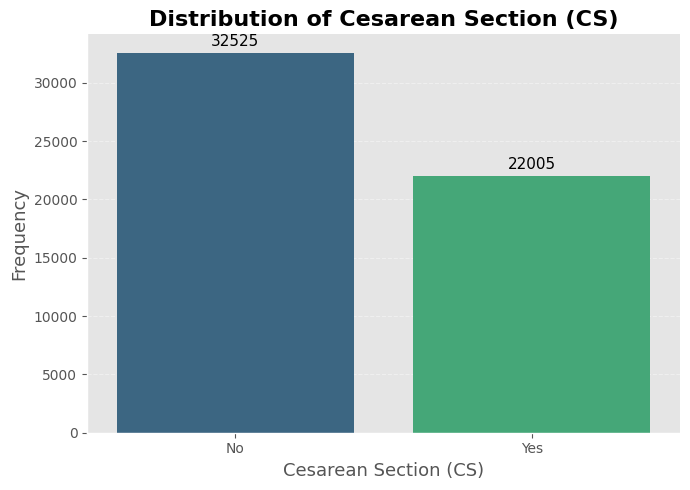

In [4]:
plt.figure(figsize=(7,5))

# Countplot
ax = sns.countplot(
    x='Cesarean Section',
    data=df,
    palette='viridis'
)

# Rename x-axis labels
ax.set_xticklabels(['No', 'Yes'])

# Add frequency labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        fontsize=11,
        padding=3
    )

# Title and labels
plt.title(
    "Distribution of Cesarean Section (CS)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Cesarean Section (CS)", fontsize=13)
plt.ylabel("Frequency", fontsize=13)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Remove unnecessary borders
sns.despine()

plt.tight_layout()
plt.show()

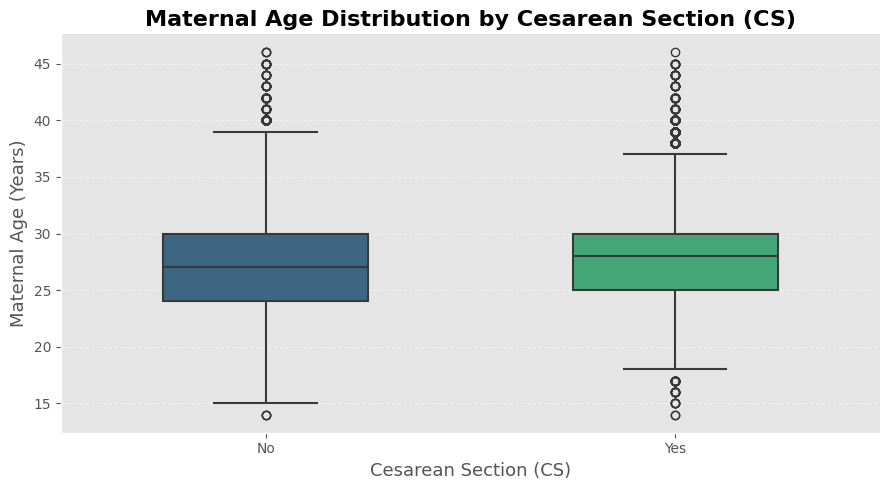

In [5]:
plt.figure(figsize=(9,5))

# Boxplot
ax = sns.boxplot(
    x='Cesarean Section',
    y='maternal_age_years',
    data=df,
    palette='viridis',
    width=0.5,
    linewidth=1.5
)

# Rename x-axis labels
ax.set_xticklabels(['No', 'Yes'])

# Title and labels
plt.title(
    "Maternal Age Distribution by Cesarean Section (CS)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Cesarean Section (CS)", fontsize=13)
plt.ylabel("Maternal Age (Years)", fontsize=13)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Remove unnecessary borders
sns.despine()

plt.tight_layout()
plt.show()

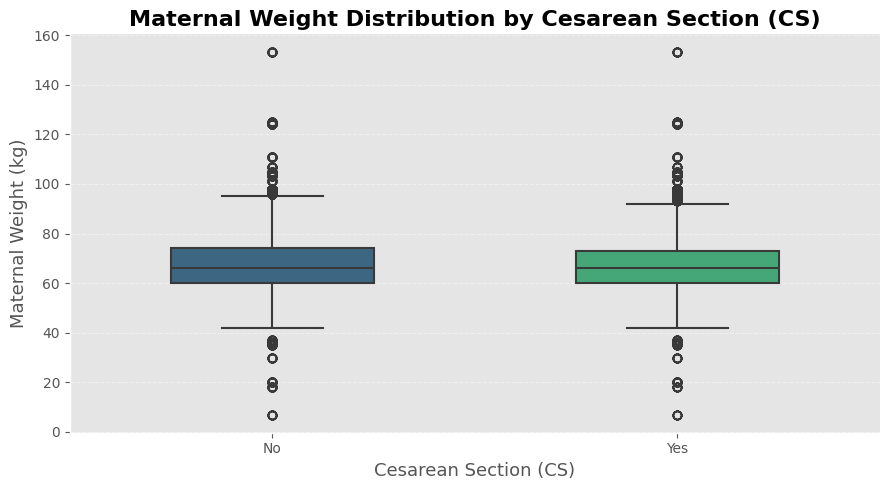

In [6]:
plt.figure(figsize=(9,5))

# Boxplot
ax = sns.boxplot(
    x='Cesarean Section',
    y='maternal_weight_kg',
    data=df,
    palette='viridis',
    width=0.5,
    linewidth=1.5
)

# Rename x-axis labels
ax.set_xticklabels(['No', 'Yes'])

# Title and labels
plt.title(
    "Maternal Weight Distribution by Cesarean Section (CS)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Cesarean Section (CS)", fontsize=13)
plt.ylabel("Maternal Weight (kg)", fontsize=13)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Remove unnecessary borders
sns.despine()

plt.tight_layout()
plt.show()

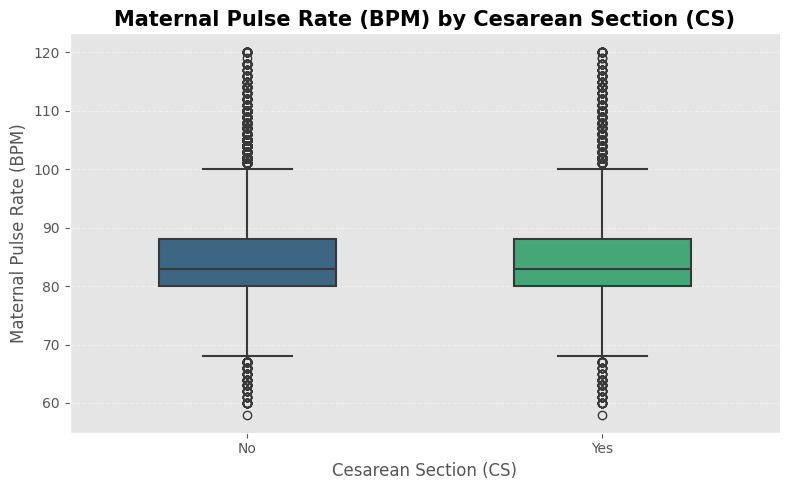

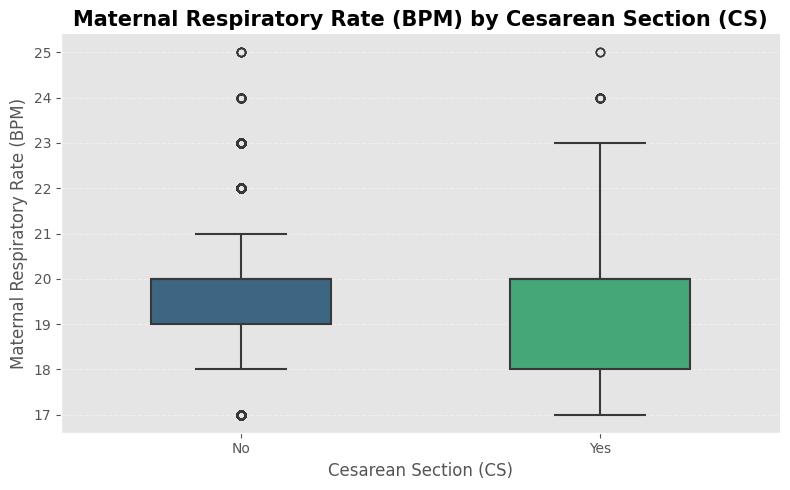

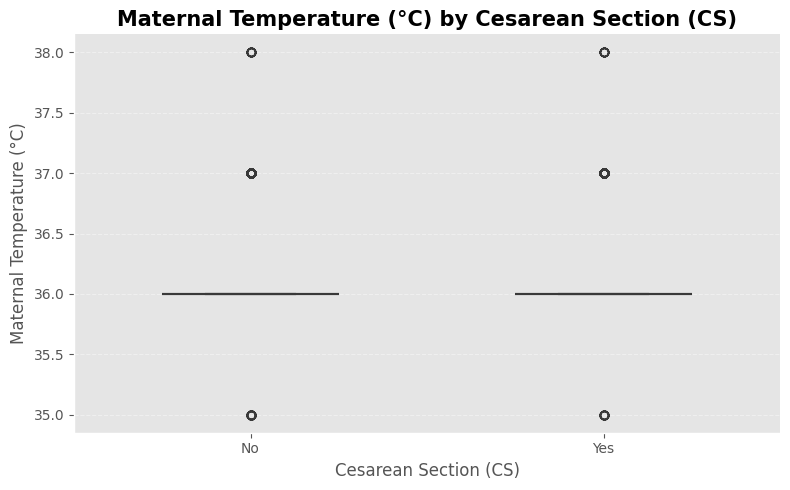

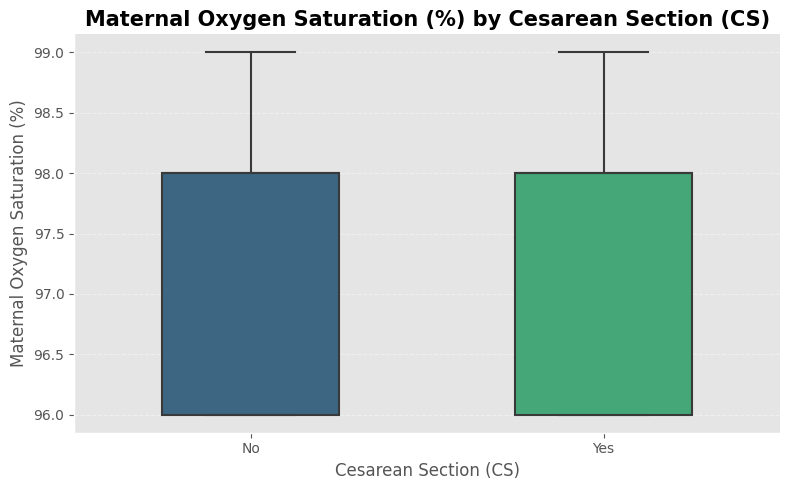

In [7]:
vitals = [
    'maternal_pulse_rate_bpm',
    'maternal_respiratory_rate_bpm',
    'maternal_temperature_c',
    'maternal_oxygen_saturation_percent'
]

# Better readable labels
vital_labels = {
    'maternal_pulse_rate_bpm': 'Maternal Pulse Rate (BPM)',
    'maternal_respiratory_rate_bpm': 'Maternal Respiratory Rate (BPM)',
    'maternal_temperature_c': 'Maternal Temperature (°C)',
    'maternal_oxygen_saturation_percent': 'Maternal Oxygen Saturation (%)'
}

for col in vitals:
    
    plt.figure(figsize=(8,5))

    # Boxplot
    ax = sns.boxplot(
        x='Cesarean Section',
        y=col,
        data=df,
        palette='viridis',
        width=0.5,
        linewidth=1.5
    )

    # Rename x-axis labels
    ax.set_xticklabels(['No', 'Yes'])

    # Titles and labels
    plt.title(
        f"{vital_labels[col]} by Cesarean Section (CS)",
        fontsize=15,
        fontweight='bold'
    )

    plt.xlabel("Cesarean Section (CS)", fontsize=12)
    plt.ylabel(vital_labels[col], fontsize=12)

    # Grid
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    # Remove unnecessary borders
    sns.despine()

    plt.tight_layout()
    plt.show()

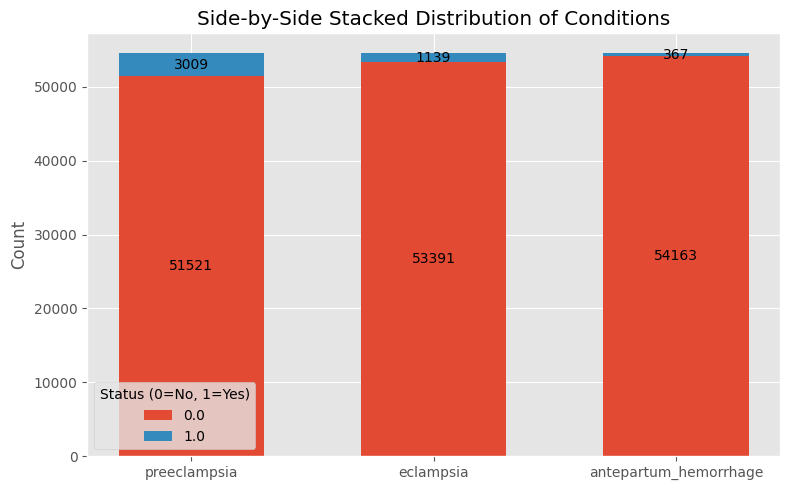

In [8]:
conditions = ['preeclampsia', 'eclampsia', 'antepartum_hemorrhage']

# Prepare counts (assuming binary 0/1)
data = []
for col in conditions:
    counts = df[col].value_counts().sort_index()  # 0,1
    data.append(counts)

stacked_df = pd.DataFrame(data, index=conditions).fillna(0)

# Ensure columns order (0 then 1)
stacked_df = stacked_df[[0, 1]]  

# Plot
x = np.arange(len(conditions))
width = 0.6

fig, ax = plt.subplots(figsize=(8,5))

# Bottom starts at 0
bottom = np.zeros(len(conditions))

for i, col in enumerate(stacked_df.columns):
    ax.bar(x, stacked_df[col], width, bottom=bottom, label=f"{col}")
    bottom += stacked_df[col].values

# Labels
ax.set_xticks(x)
ax.set_xticklabels(conditions, rotation=0)
ax.set_title("Side-by-Side Stacked Distribution of Conditions")
ax.set_ylabel("Count")
ax.legend(title="Status (0=No, 1=Yes)")

# Add labels
for i in range(len(conditions)):
    cumulative = 0
    for col in stacked_df.columns:
        value = stacked_df.loc[conditions[i], col]
        if value > 0:
            ax.text(i, cumulative + value/2, int(value), ha='center', va='center')
            cumulative += value

plt.tight_layout()
plt.show()

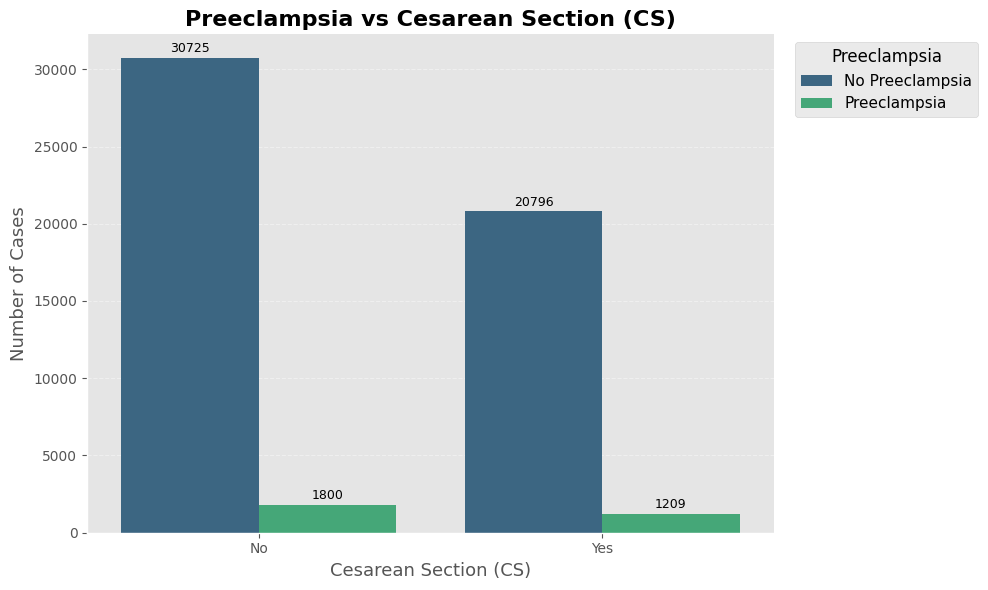

In [9]:
plt.figure(figsize=(10,6))

# Countplot
ax = sns.countplot(
    x='Cesarean Section',
    hue='preeclampsia',
    data=df,
    palette='viridis'
)

# Rename x-axis labels
ax.set_xticklabels(['No', 'Yes'])

# Rename legend labels (robust handling)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['No Preeclampsia', 'Preeclampsia'],
    title="Preeclampsia",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=11,
    title_fontsize=12
)

# Add frequency labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        fontsize=9,
        padding=2
    )

# Titles and labels
plt.title(
    "Preeclampsia vs Cesarean Section (CS)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Cesarean Section (CS)", fontsize=13)
plt.ylabel("Number of Cases", fontsize=13)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Clean borders
sns.despine()

plt.tight_layout()
plt.show()

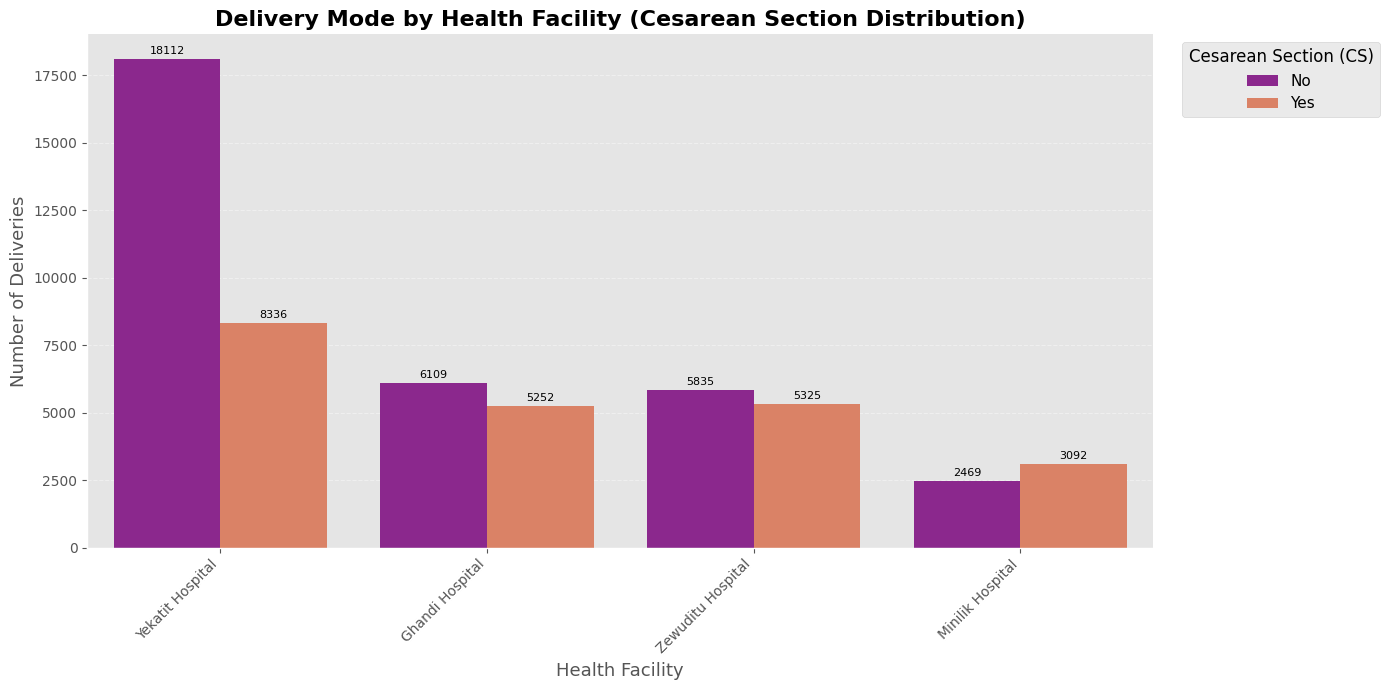

In [10]:
plt.figure(figsize=(14,7))

# Order facilities by frequency
order = df['health_facility'].value_counts().index

# Countplot
ax = sns.countplot(
    x='health_facility',
    hue='Cesarean Section',
    data=df,
    order=order,
    palette='plasma'
)

# Rename legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['No', 'Yes'],
    title="Cesarean Section (CS)",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=11,
    title_fontsize=12
)

# Add frequency labels
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=8,
        padding=2
    )

# X-axis formatting
plt.xticks(rotation=45, ha='right')

# Titles and labels
plt.title(
    "Delivery Mode by Health Facility (Cesarean Section Distribution)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Health Facility", fontsize=13)
plt.ylabel("Number of Deliveries", fontsize=13)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Clean borders
sns.despine()

plt.tight_layout()
plt.show()

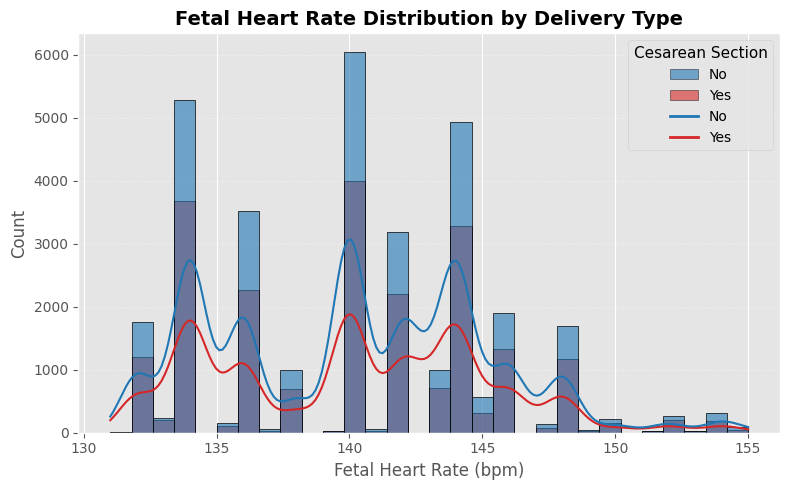

In [11]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.figure(figsize=(8,5))

ax = sns.histplot(
    data=df,
    x='fetal_heart_rate_bpm',
    hue='Cesarean Section',
    bins=30,
    kde=True,
    palette=['#1f77b4', '#d62728'],
    alpha=0.6,
    edgecolor='black',
    linewidth=0.5
)

plt.title("Fetal Heart Rate Distribution by Delivery Type", fontsize=14, weight='bold')
plt.xlabel("Fetal Heart Rate (bpm)", fontsize=12)
plt.ylabel("Count", fontsize=12)

# --- Custom Legend ---
legend_elements = [
    Patch(facecolor='#1f77b4', edgecolor='black', label='No', alpha=0.6),
    Patch(facecolor='#d62728', edgecolor='black', label='Yes', alpha=0.6),
    Line2D([0], [0], color='#1f77b4', lw=2, label='No'),
    Line2D([0], [0], color='#d62728', lw=2, label='Yes')
]

plt.legend(
    handles=legend_elements,
    title="Cesarean Section",
    title_fontsize=11,
    fontsize=10
)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

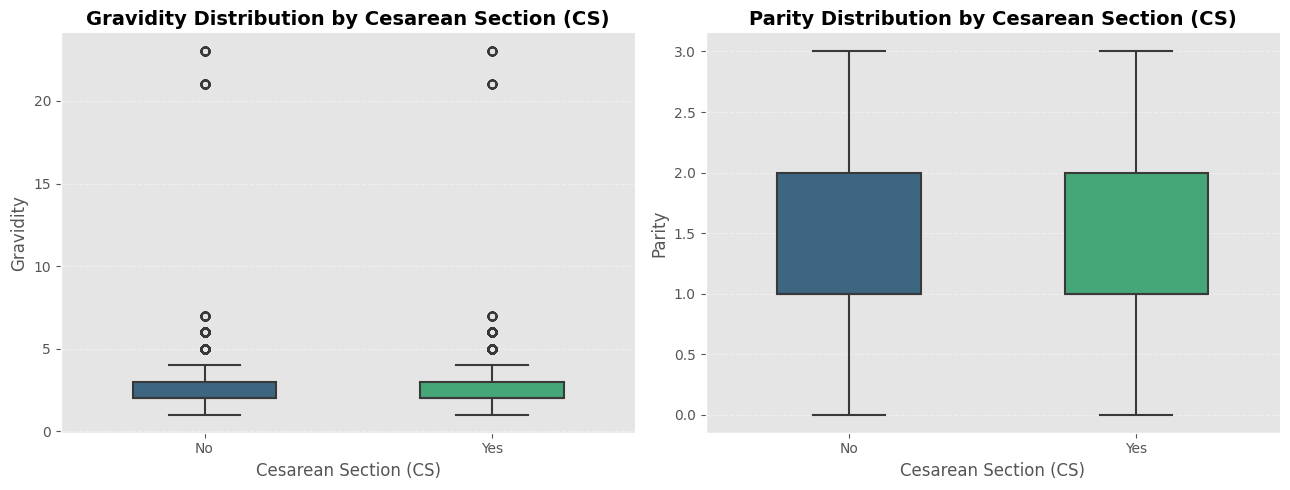

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gravidity boxplot
sns.boxplot(
    x='Cesarean Section',
    y='gravidity',
    data=df,
    ax=axes[0],
    palette='viridis',
    width=0.5,
    linewidth=1.5
)

axes[0].set_title(
    "Gravidity Distribution by Cesarean Section (CS)",
    fontsize=14,
    fontweight='bold'
)
axes[0].set_xlabel("Cesarean Section (CS)", fontsize=12)
axes[0].set_ylabel("Gravidity", fontsize=12)
axes[0].set_xticklabels(['No', 'Yes'])
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(ax=axes[0])

# Parity boxplot
sns.boxplot(
    x='Cesarean Section',
    y='parity',
    data=df,
    ax=axes[1],
    palette='viridis',
    width=0.5,
    linewidth=1.5
)

axes[1].set_title(
    "Parity Distribution by Cesarean Section (CS)",
    fontsize=14,
    fontweight='bold'
)
axes[1].set_xlabel("Cesarean Section (CS)", fontsize=12)
axes[1].set_ylabel("Parity", fontsize=12)
axes[1].set_xticklabels(['No', 'Yes'])
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

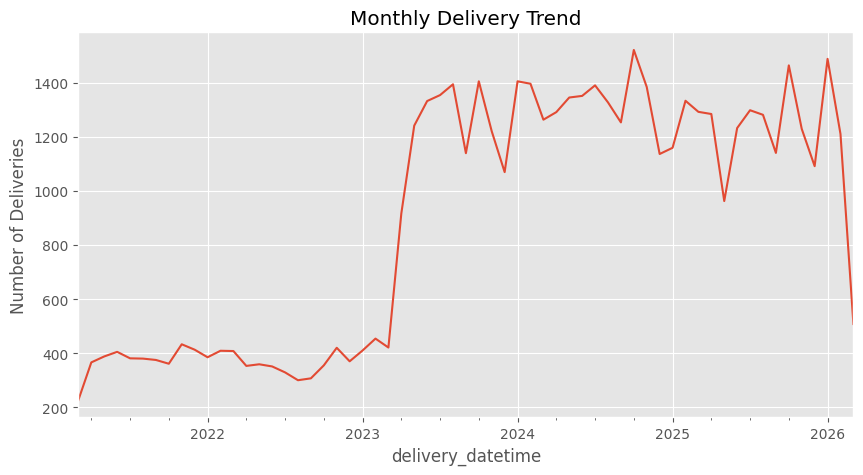

In [13]:
df['delivery_datetime'] = pd.to_datetime(df['delivery_datetime'], errors='coerce')

df.groupby(df['delivery_datetime'].dt.to_period('M')).size().plot(figsize=(10,5))

plt.title("Monthly Delivery Trend")
plt.ylabel("Number of Deliveries")
plt.show()

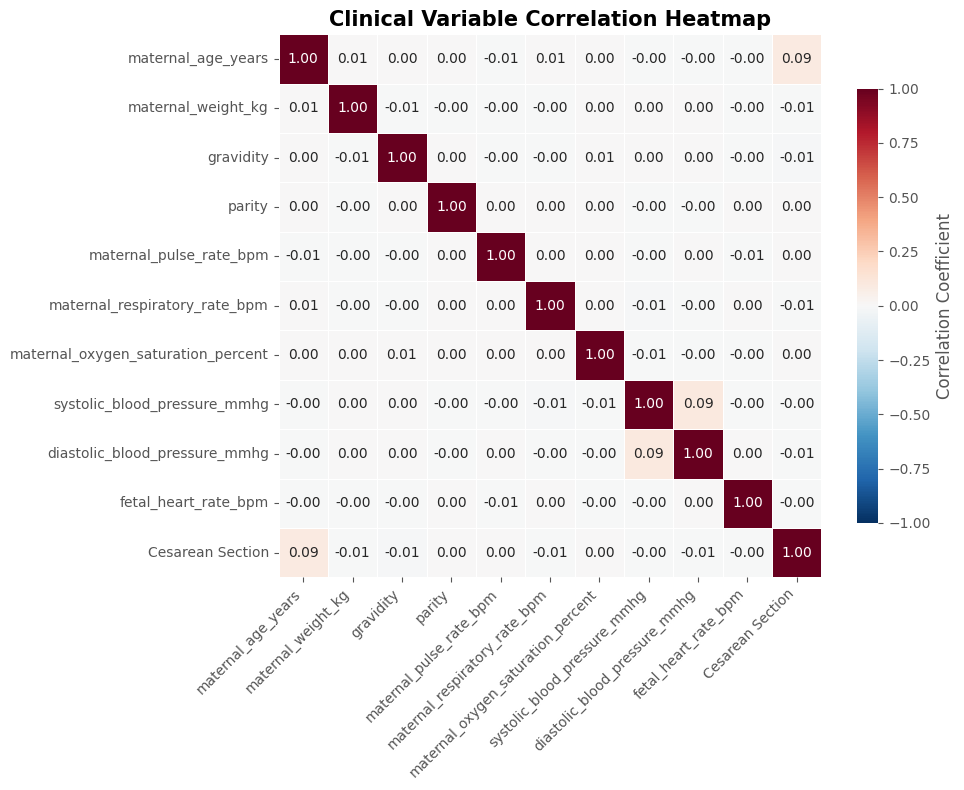

In [14]:
selected_cols = [
    'maternal_age_years', 'maternal_weight_kg',
    'gravidity', 'parity',
    'maternal_pulse_rate_bpm',
    'maternal_respiratory_rate_bpm',
    'maternal_oxygen_saturation_percent',
    'systolic_blood_pressure_mmhg',
    'diastolic_blood_pressure_mmhg',
    'fetal_heart_rate_bpm',
    'Cesarean Section'
]

corr_df = df[selected_cols].copy().dropna()
corr = corr_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap='RdBu_r',          # 🔥 BEST for correlations (blue ↔ red)
    vmin=-1, vmax=1,        # consistent scale
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)

plt.title("Clinical Variable Correlation Heatmap", fontsize=15, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

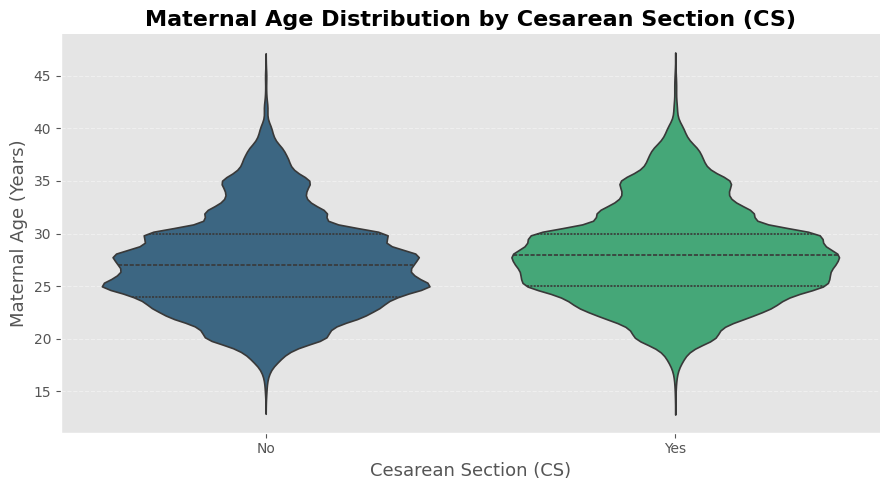

In [15]:
plt.figure(figsize=(9,5))

# Violin plot
ax = sns.violinplot(
    x='Cesarean Section',
    y='maternal_age_years',
    data=df,
    palette='viridis',
    inner='quartile',
    linewidth=1.2
)

# Rename x-axis labels
ax.set_xticklabels(['No', 'Yes'])

# Title and labels
plt.title(
    "Maternal Age Distribution by Cesarean Section (CS)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Cesarean Section (CS)", fontsize=13)
plt.ylabel("Maternal Age (Years)", fontsize=13)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Clean borders
sns.despine()

plt.tight_layout()
plt.show()

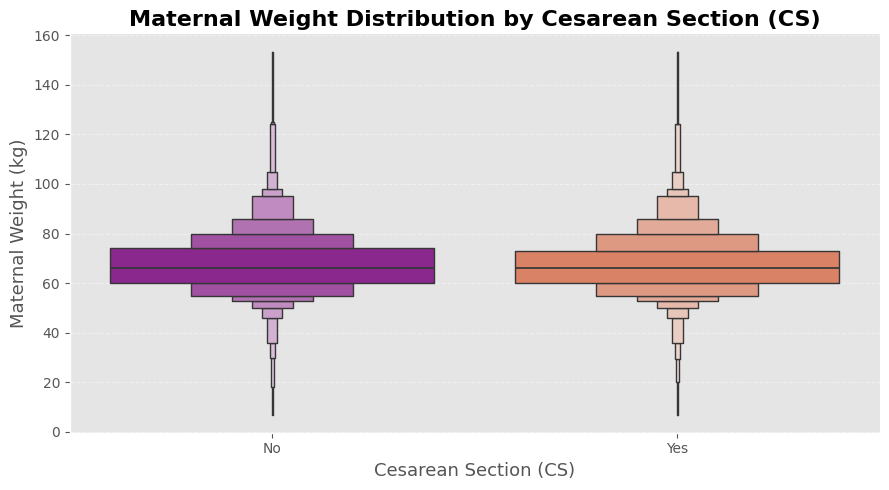

In [16]:
plt.figure(figsize=(9,5))

# Boxen plot
ax = sns.boxenplot(
    x='Cesarean Section',
    y='maternal_weight_kg',
    data=df,
    palette='plasma',
    linewidth=1
)

# Rename x-axis labels
ax.set_xticklabels(['No', 'Yes'])

# Title and labels
plt.title(
    "Maternal Weight Distribution by Cesarean Section (CS)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Cesarean Section (CS)", fontsize=13)
plt.ylabel("Maternal Weight (kg)", fontsize=13)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Clean borders
sns.despine()

plt.tight_layout()
plt.show()

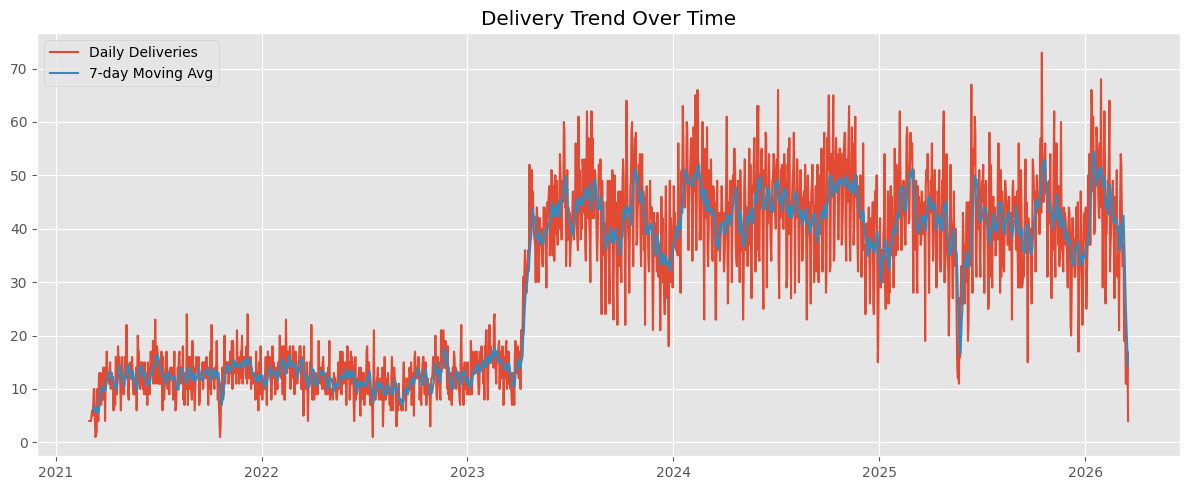

In [17]:
df['delivery_datetime'] = pd.to_datetime(df['delivery_datetime'], errors='coerce')

time_series = df.groupby(df['delivery_datetime'].dt.date).size()

rolling = time_series.rolling(7).mean()

plt.figure(figsize=(12,5))

plt.plot(time_series, label='Daily Deliveries')
plt.plot(rolling, label='7-day Moving Avg')

plt.title("Delivery Trend Over Time")
plt.legend()
plt.tight_layout()
plt.show()

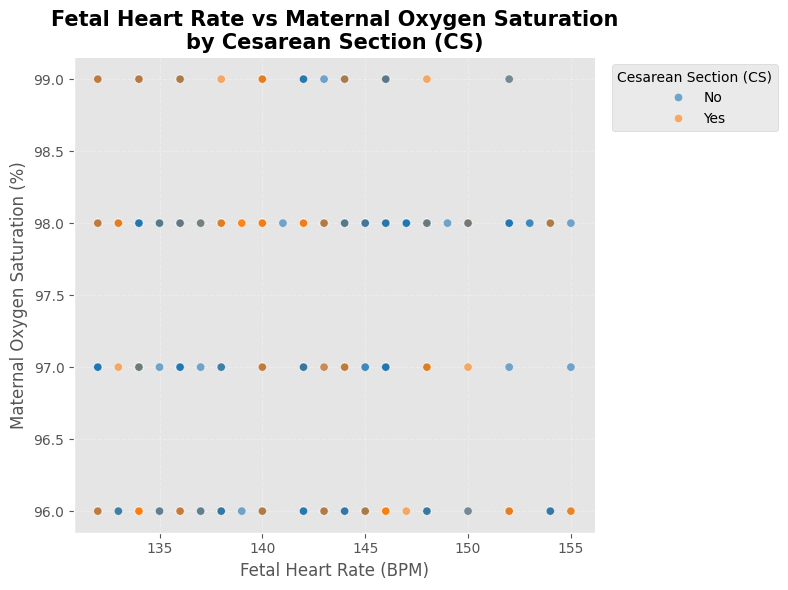

In [18]:
plt.figure(figsize=(8,6))

# sample for performance
sample_df = df.sample(2000, random_state=42)

# Scatter plot with clean binary palette
ax = sns.scatterplot(
    x='fetal_heart_rate_bpm',
    y='maternal_oxygen_saturation_percent',
    hue='Cesarean Section',
    data=sample_df,
    palette={0: "tab:blue", 1: "tab:orange"},
    alpha=0.6
)

# Rename legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['No', 'Yes'],
    title="Cesarean Section (CS)",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Titles and labels
plt.title(
    "Fetal Heart Rate vs Maternal Oxygen Saturation\nby Cesarean Section (CS)",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Fetal Heart Rate (BPM)", fontsize=12)
plt.ylabel("Maternal Oxygen Saturation (%)", fontsize=12)

# Grid
plt.grid(True, linestyle='--', alpha=0.3)

# Clean borders
sns.despine()

plt.tight_layout()
plt.show()

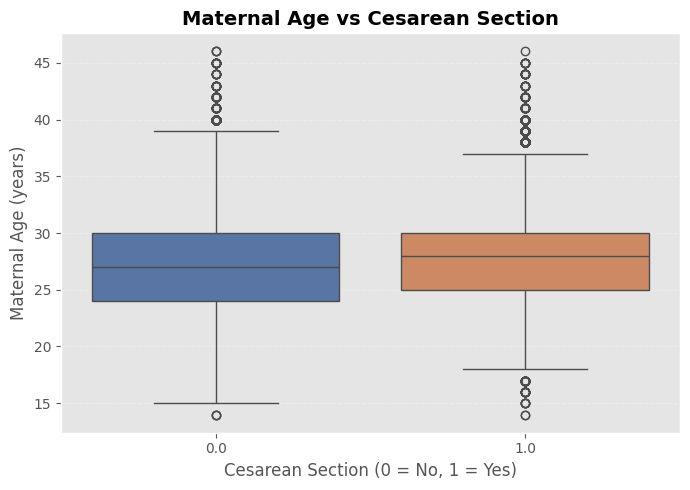

In [19]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Cesarean Section',
    y='maternal_age_years',
    palette=['#4C72B0', '#DD8452']
)

plt.title("Maternal Age vs Cesarean Section", fontsize=14, weight='bold')
plt.xlabel("Cesarean Section (0 = No, 1 = Yes)")
plt.ylabel("Maternal Age (years)")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

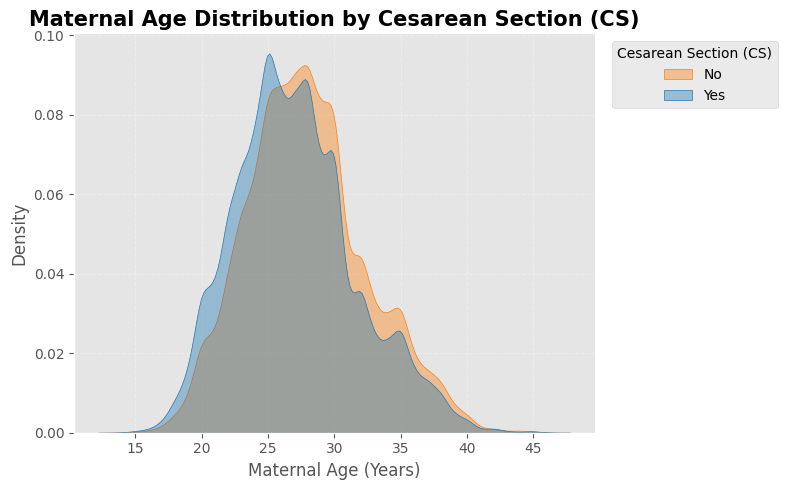

In [20]:
plt.figure(figsize=(8,5))

# KDE plot
ax = sns.kdeplot(
    data=df,
    x='maternal_age_years',
    hue='Cesarean Section',
    fill=True,
    common_norm=False,
    palette={0: "#1f77b4", 1: "#ff7f0e"},
    alpha=0.4
)

# Force correct legend labels from hue levels
hue_labels = ['No', 'Yes']

# Build legend manually (most reliable fix)
handles = ax.collections[:2]  # KDE fill layers
ax.legend(
    handles,
    hue_labels,
    title="Cesarean Section (CS)",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Titles and labels
plt.title(
    "Maternal Age Distribution by Cesarean Section (CS)",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Maternal Age (Years)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Grid
plt.grid(alpha=0.3, linestyle='--')

# Clean borders
sns.despine()

plt.tight_layout()
plt.show()

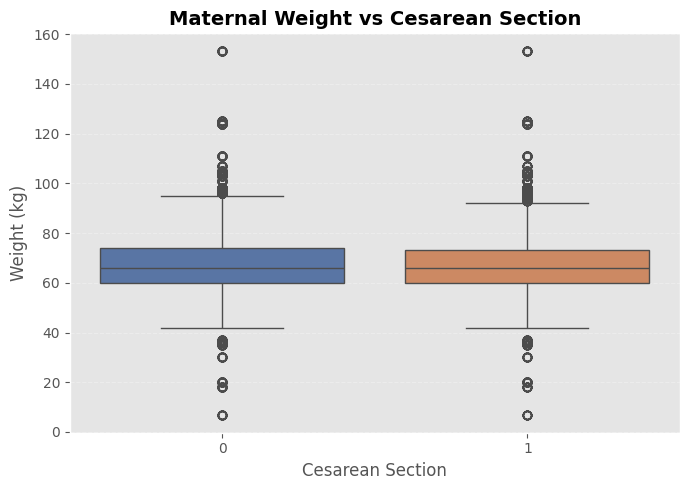

In [30]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Cesarean Section',
    y='maternal_weight_kg',
    palette=['#4C72B0', '#DD8452']
)

plt.title("Maternal Weight vs Cesarean Section", fontsize=14, weight='bold')
plt.xlabel("Cesarean Section")
plt.ylabel("Weight (kg)")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

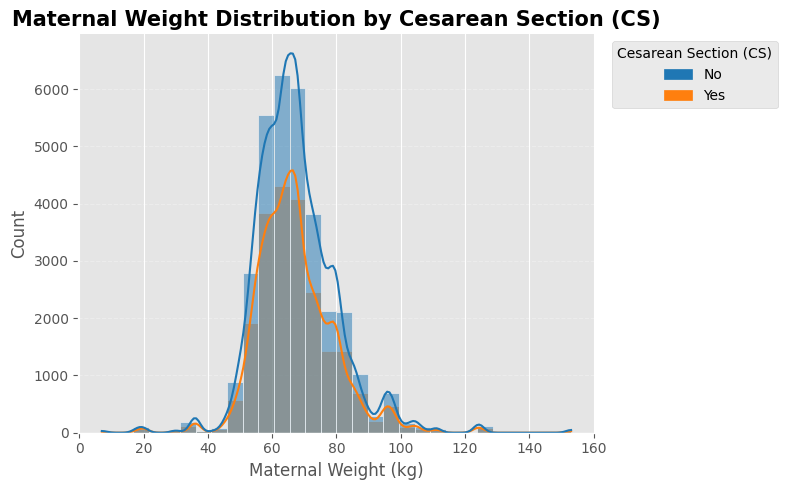

In [22]:
plt.figure(figsize=(8,5))

# Clean CS column
df['Cesarean Section'] = pd.to_numeric(df['Cesarean Section'], errors='coerce').astype('Int64')

# Histogram with fixed hue order
ax = sns.histplot(
    data=df,
    x='maternal_weight_kg',
    hue='Cesarean Section',
    hue_order=[0, 1],
    bins=30,
    kde=True,
    palette={0: "#1f77b4", 1: "#ff7f0e"},
    alpha=0.5
)

# 🔥 Force correct legend (robust fix)
ax.legend_.remove()  # remove broken auto legend

ax.legend(
    handles=[
        plt.Rectangle((0,0),1,1,color="#1f77b4"),
        plt.Rectangle((0,0),1,1,color="#ff7f0e")
    ],
    labels=['No', 'Yes'],
    title="Cesarean Section (CS)",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Titles and labels
plt.title(
    "Maternal Weight Distribution by Cesarean Section (CS)",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Maternal Weight (kg)", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

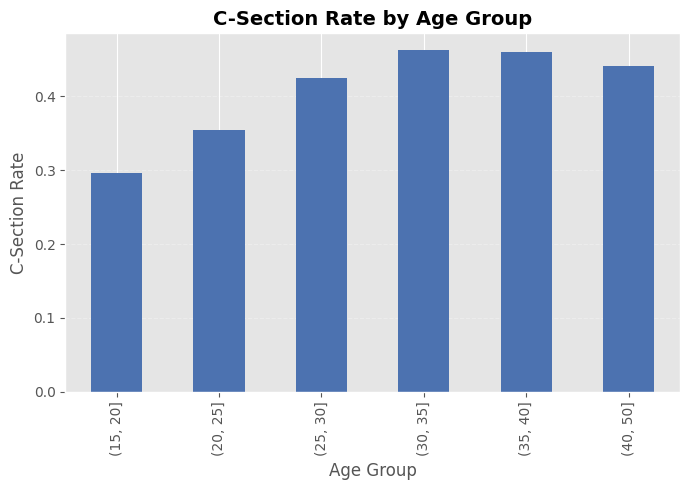

In [23]:
df['age_group'] = pd.cut(
    df['maternal_age_years'],
    bins=[15, 20, 25, 30, 35, 40, 50]
)

age_cs = df.groupby('age_group')['Cesarean Section'].mean()

age_cs.plot(kind='bar', figsize=(7,5), color='#4C72B0')

plt.title("C-Section Rate by Age Group", fontsize=14, weight='bold')
plt.ylabel("C-Section Rate")
plt.xlabel("Age Group")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

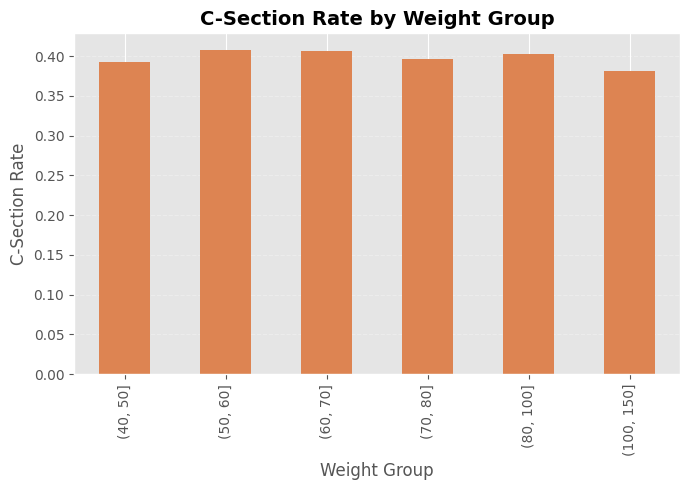

In [24]:
df['weight_group'] = pd.cut(
    df['maternal_weight_kg'],
    bins=[40, 50, 60, 70, 80, 100, 150]
)

weight_cs = df.groupby('weight_group')['Cesarean Section'].mean()

weight_cs.plot(kind='bar', figsize=(7,5), color='#DD8452')

plt.title("C-Section Rate by Weight Group", fontsize=14, weight='bold')
plt.ylabel("C-Section Rate")
plt.xlabel("Weight Group")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

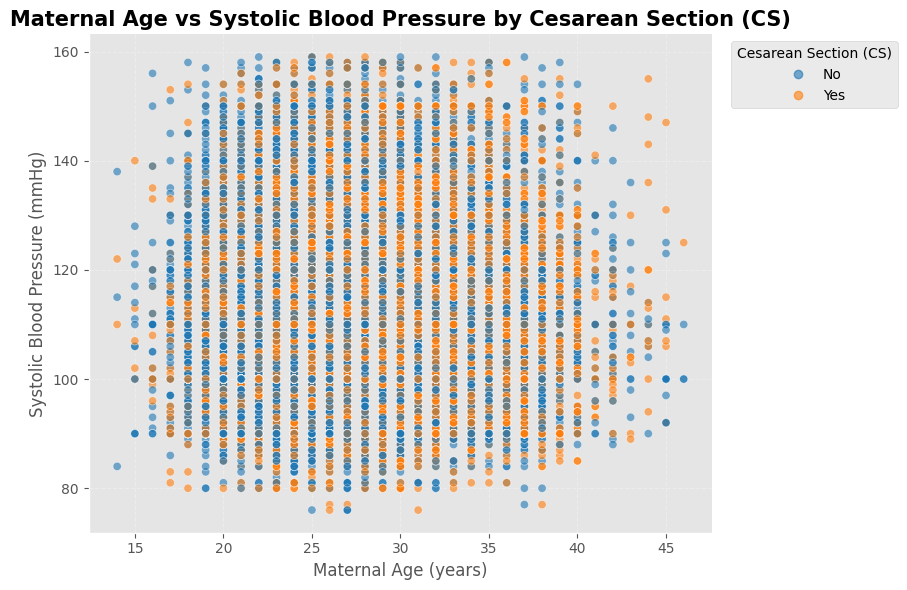

In [25]:
plt.figure(figsize=(9,6))

# Ensure clean encoding
df['Cesarean Section'] = pd.to_numeric(df['Cesarean Section'], errors='coerce').astype('Int64')

# Scatter plot
ax = sns.scatterplot(
    data=df,
    x='maternal_age_years',
    y='systolic_blood_pressure_mmhg',
    hue='Cesarean Section',
    hue_order=[0, 1],
    palette={0: "#1f77b4", 1: "#ff7f0e"},
    alpha=0.6
)

# 🔥 Fix legend properly
ax.legend_.remove()

ax.legend(
    handles=[
        plt.Line2D([], [], marker='o', linestyle='', color="#1f77b4", label='No', alpha=0.6),
        plt.Line2D([], [], marker='o', linestyle='', color="#ff7f0e", label='Yes', alpha=0.6)
    ],
    title="Cesarean Section (CS)",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Titles and labels
plt.title(
    "Maternal Age vs Systolic Blood Pressure by Cesarean Section (CS)",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Maternal Age (years)", fontsize=12)
plt.ylabel("Systolic Blood Pressure (mmHg)", fontsize=12)

# Grid
plt.grid(True, linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

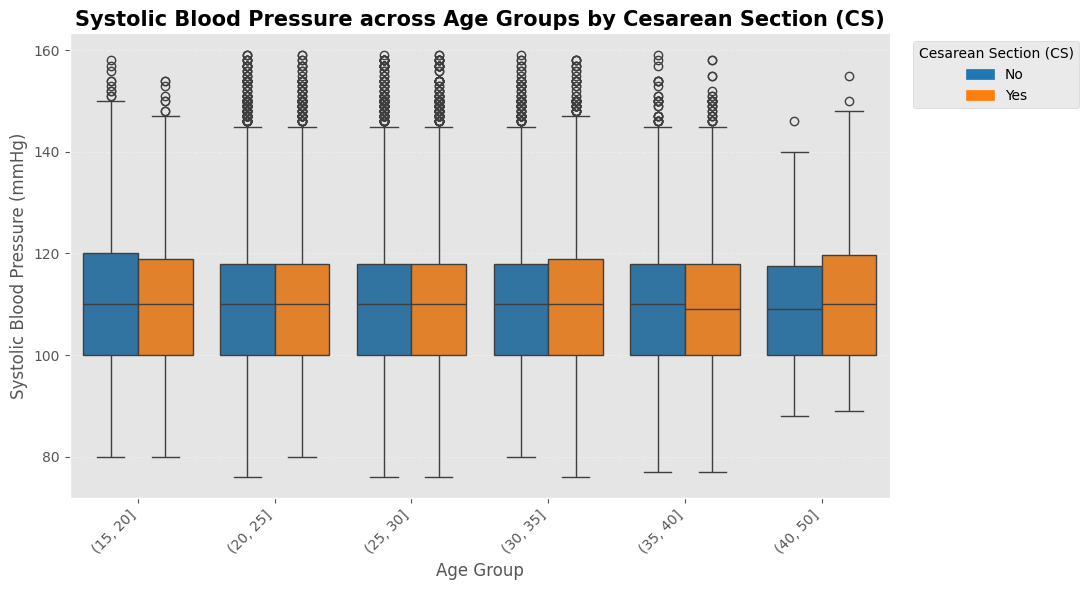

In [26]:
plt.figure(figsize=(11,6))

# Ensure clean encoding
df['Cesarean Section'] = pd.to_numeric(df['Cesarean Section'], errors='coerce').astype('Int64')

# Boxplot
ax = sns.boxplot(
    data=df,
    x='age_group',
    y='systolic_blood_pressure_mmhg',
    hue='Cesarean Section',
    hue_order=[0, 1],
    palette={0: "#1f77b4", 1: "#ff7f0e"}
)

# 🔥 Fix legend
ax.legend_.remove()

ax.legend(
    handles=[
        plt.Rectangle((0,0),1,1,color="#1f77b4"),
        plt.Rectangle((0,0),1,1,color="#ff7f0e")
    ],
    labels=['No', 'Yes'],
    title="Cesarean Section (CS)",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Titles and labels
plt.title(
    "Systolic Blood Pressure across Age Groups by Cesarean Section (CS)",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Systolic Blood Pressure (mmHg)", fontsize=12)

# Formatting
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

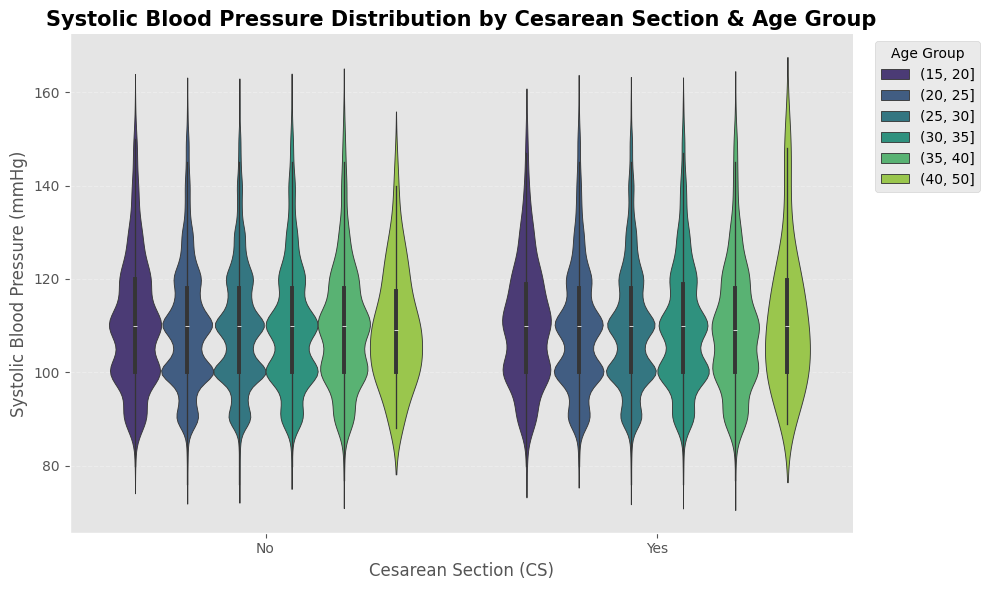

In [27]:
plt.figure(figsize=(10,6))

# Ensure clean encoding
df['Cesarean Section'] = pd.to_numeric(df['Cesarean Section'], errors='coerce').astype('Int64')

# Violin plot
ax = sns.violinplot(
    data=df,
    x='Cesarean Section',
    y='systolic_blood_pressure_mmhg',
    hue='age_group',
    split=False,   # safer (split=True often breaks when hue has >2 groups)
    palette='viridis'
)

# 🔥 Fix x-axis labels
ax.set_xticklabels(['No', 'Yes'])

# Titles and labels
plt.title(
    "Systolic Blood Pressure Distribution by Cesarean Section & Age Group",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Cesarean Section (CS)", fontsize=12)
plt.ylabel("Systolic Blood Pressure (mmHg)", fontsize=12)

# Legend placement (age groups)
plt.legend(
    title="Age Group",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Grid + styling
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

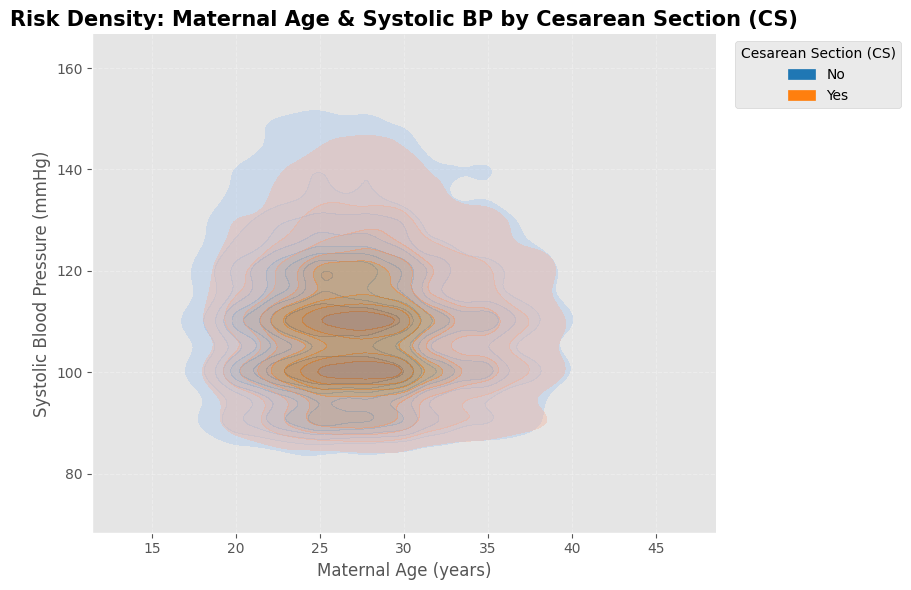

In [28]:
plt.figure(figsize=(9,6))

# Ensure clean encoding
df['Cesarean Section'] = pd.to_numeric(df['Cesarean Section'], errors='coerce').astype('Int64')

# 2D KDE plot
ax = sns.kdeplot(
    data=df,
    x='maternal_age_years',
    y='systolic_blood_pressure_mmhg',
    hue='Cesarean Section',
    hue_order=[0, 1],
    fill=True,
    alpha=0.4,
    palette={0: "#1f77b4", 1: "#ff7f0e"}
)

# 🔥 Fix legend
ax.legend_.remove()

ax.legend(
    handles=[
        plt.Rectangle((0,0),1,1,color="#1f77b4"),
        plt.Rectangle((0,0),1,1,color="#ff7f0e")
    ],
    labels=['No', 'Yes'],
    title="Cesarean Section (CS)",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Titles and labels
plt.title(
    "Risk Density: Maternal Age & Systolic BP by Cesarean Section (CS)",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Maternal Age (years)", fontsize=12)
plt.ylabel("Systolic Blood Pressure (mmHg)", fontsize=12)

# Grid + styling
plt.grid(True, linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()